In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


In [30]:

ATOZ_DIR = os.path.join(os.getcwd(), "ATOZ")

TRAIN_DIR = os.path.join(ATOZ_DIR, "Training")
TEST_DIR = os.path.join(ATOZ_DIR, "Testing")

print("Training path:", TRAIN_DIR)
print("Testing path:", TEST_DIR)

Training path: C:\Users\Razik Rahman\Downloads\ATOZ\Training
Testing path: C:\Users\Razik Rahman\Downloads\ATOZ\Testing


In [31]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 18154 files belonging to 26 classes.
Found 5200 files belonging to 26 classes.
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 26


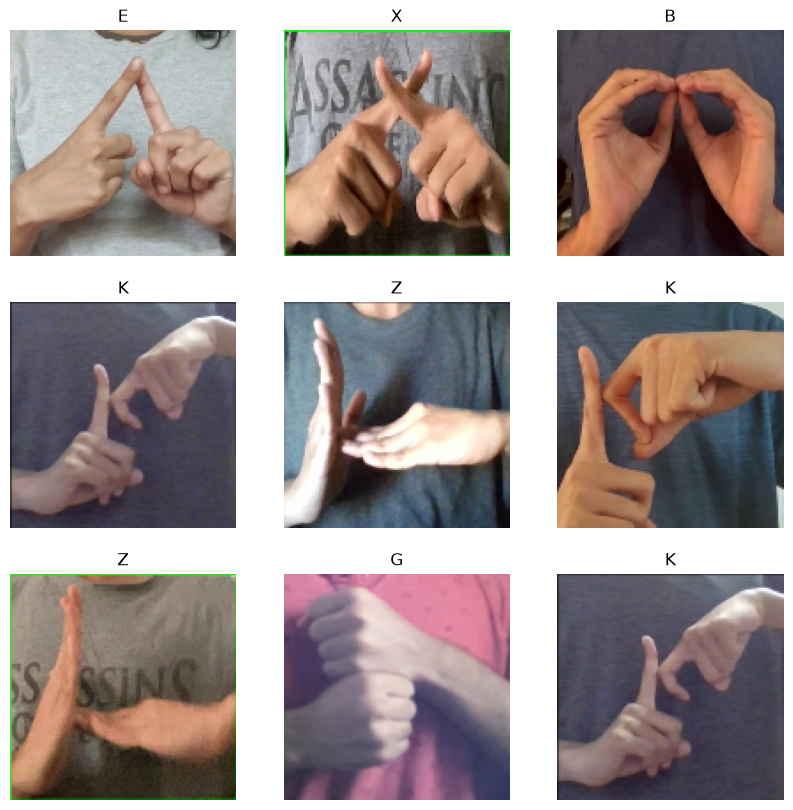

In [32]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [33]:
from PIL import Image

bad_files = []

for folder in [TRAIN_DIR, TEST_DIR]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
                path = os.path.join(root, file)

                try:
                    with Image.open(path) as img:
                        img.verify()
                except Exception:
                    bad_files.append(path)

print("Bad image files:", len(bad_files))

for file in bad_files[:50]:
    print(file)

Bad image files: 0


In [34]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names

print("Training classes:", len(class_names))
print("Testing classes:", len(test_ds.class_names))

Found 18154 files belonging to 26 classes.
Found 5200 files belonging to 26 classes.
Training classes: 26
Testing classes: 26


In [35]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [37]:
model = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(26, activation="softmax")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,307,994 (12.62 MB)

 Trainable params: 3,307,994 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [39]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.5018 - loss: 1.6551 - val_accuracy: 0.8317 - val_loss: 1.1885
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - accuracy: 0.8517 - loss: 0.4558 - val_accuracy: 0.8585 - val_loss: 1.1740
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - accuracy: 0.9047 - loss: 0.2822 - val_accuracy: 0.8635 - val_loss: 1.4729
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.9239 - loss: 0.2276 - val_accuracy: 0.8635 - val_loss: 1.3585
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - accuracy: 0.9377 - loss: 0.1877 - val_accuracy: 0.8642 - val_loss: 1.6425
Epoch 6/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.9456 - loss: 0.1631 - val_accuracy: 0.8625 - val_loss: 1.9106
Epoch 7/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.9482 - loss: 0.1552 - val_accuracy: 0.8644 - val_loss: 1.9612
Epoch 8/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9575 - loss: 0.1293 - 

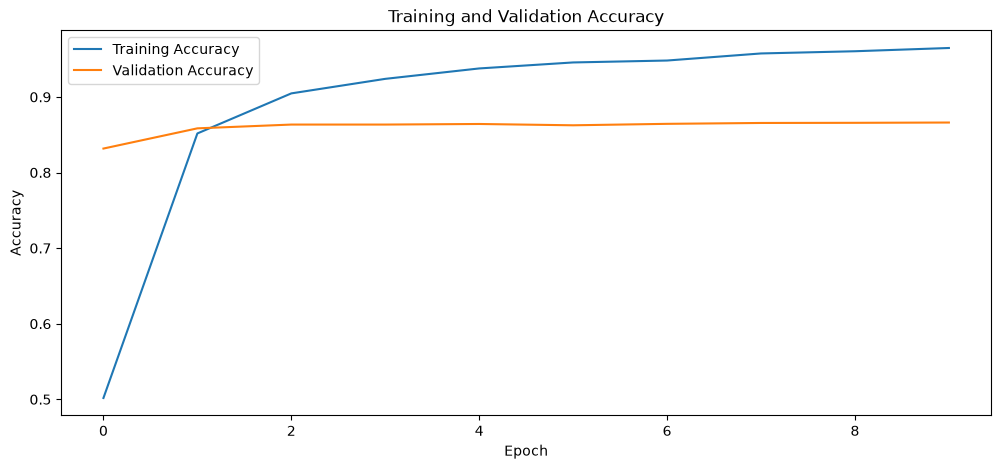

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

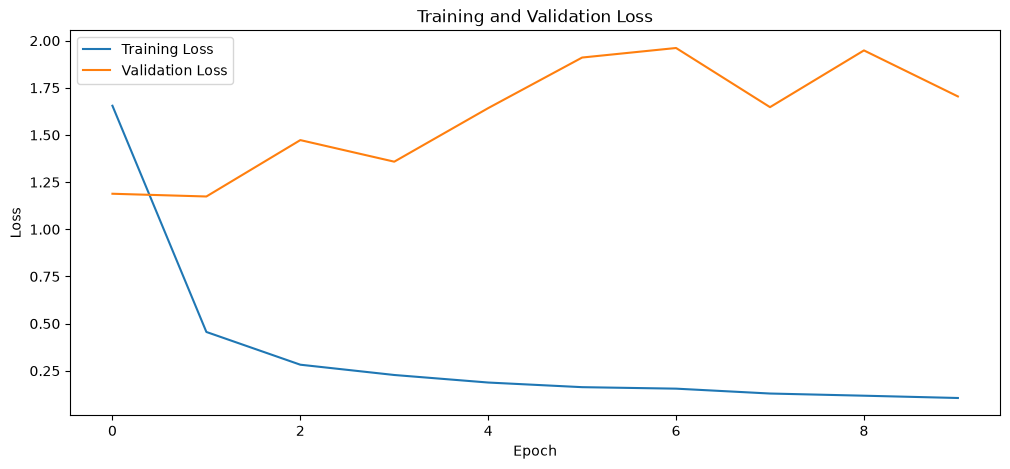

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [42]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", f"{test_accuracy * 100:.2f}%")

163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8662 - loss: 1.7044
Test Loss: 1.7044028043746948
Test Accuracy: 86.62%


In [44]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

Predictions generated successfully!


In [45]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       200
           B       0.85      1.00      0.92       200
           C       1.00      0.95      0.97       200
           D       0.72      1.00      0.84       200
           E       0.96      1.00      0.98       199
           F       0.69      0.99      0.82       200
           G       1.00      1.00      1.00       200
           H       1.00      1.00      1.00       200
           I       0.83      0.75      0.79       200
           J       1.00      1.00      1.00       200
           K       0.93      1.00      0.97       200
           L       0.93      1.00      0.97       200
           M       1.00      1.00      1.00       200
           N       0.80      1.00      0.89       200
           O       0.65      0.99      0.78       200
           P       0.99      1.00      1.00       200
           Q       1.00      0.75      0.86       200
           R       1.00    

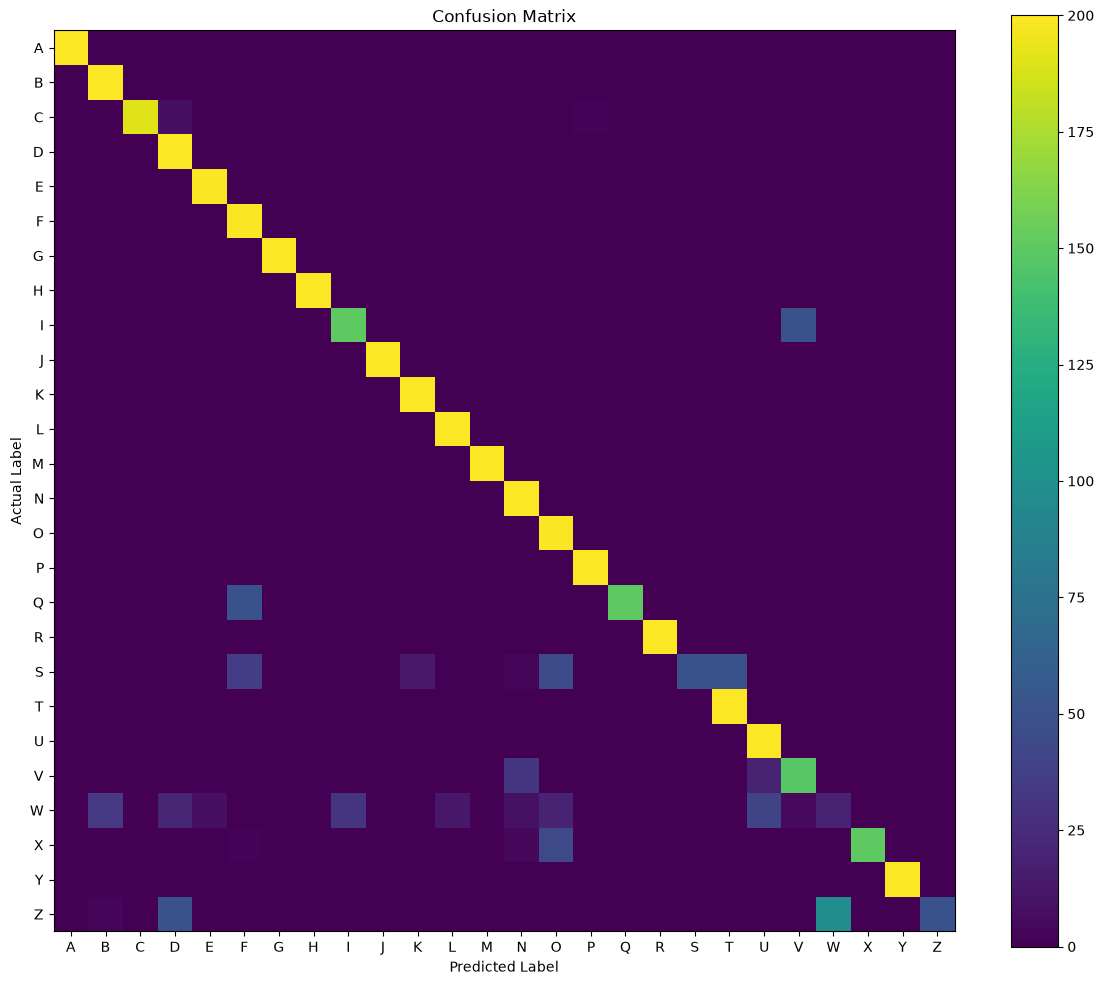

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

In [47]:
MODEL_PATH = "isl_alphabet_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Path:", MODEL_PATH)

Model saved successfully!
Path: isl_alphabet_cnn.keras


In [48]:
loaded_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [49]:
sample_images, sample_labels = next(iter(test_ds))

predictions = loaded_model.predict(sample_images, verbose=0)

for i in range(10):
    predicted_index = np.argmax(predictions[i])
    actual_index = sample_labels[i].numpy()

    print(
        "Actual:", class_names[actual_index],
        "| Predicted:", class_names[predicted_index]
    )

Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A


In [50]:
sample_images, sample_labels = next(iter(test_ds))

predictions = loaded_model.predict(sample_images, verbose=0)

for i in range(10):
    predicted_index = np.argmax(predictions[i])
    actual_index = sample_labels[i].numpy()

    print(
        "Actual:", class_names[actual_index],
        "| Predicted:", class_names[predicted_index]
    )

Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A
Actual: A | Predicted: A


In [51]:
def predict_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = loaded_model.predict(img_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    confidence = prediction[0][predicted_index]

    return class_names[predicted_index], confidence

In [ ]:
image_path = input("Enter image path: ")

prediction, confidence = predict_image(image_path)

print("Predicted Letter:", prediction)
print("Confidence:", f"{confidence * 100:.2f}%")

Image: C:\Users\Razik Rahman\Downloads\ATOZ\Testing\A\175.jpg
Predicted Letter: A
Confidence: 100.00%


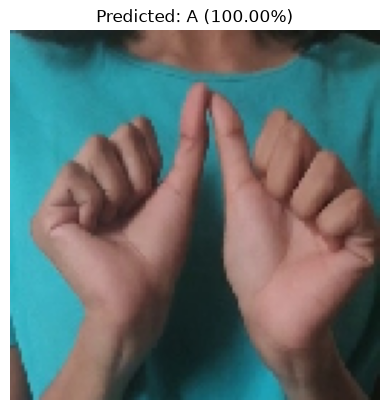

In [54]:
image_path = os.path.join(
    TEST_DIR,
    "A",
    os.listdir(os.path.join(TEST_DIR, "A"))[0]
)

prediction, confidence = predict_image(image_path)

print("Image:", image_path)
print("Predicted Letter:", prediction)
print("Confidence:", f"{confidence * 100:.2f}%")

img = tf.keras.utils.load_img(
    image_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

plt.imshow(img)
plt.title(
    f"Predicted: {prediction} ({confidence * 100:.2f}%)"
)
plt.axis("off")
plt.show()